<a href="https://colab.research.google.com/github/Saifullah785/Predictive_Maintenance_ML_Projects/blob/main/Project_01_Predictive_Maintenance_Using_Machine_Learning/Project_01_Predictive_Maintenance_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import accuracy_score, classification_report, recall_score, precision_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")


In [3]:
# Define the column names
column_names = ['Temperature', 'Vibration', 'Pressure', 'Humidity', 'RPM', 'Voltage', 'Current', 'Sound_Level', 'Oil_Quality', 'Load','Machine Type','Failure Type','Component Type']

# Generate random data for each column
num_rows = 100
data = {
    'Temperature': np.random.uniform(20, 100, num_rows),  # Temperature between 20 and 100
    'Vibration': np.random.uniform(0, 1, num_rows),  # Vibration between 0 and 1
    'Pressure': np.random.uniform(1, 10, num_rows),  # Pressure between 1 and 10
    'Humidity': np.random.uniform(30, 80, num_rows),  # Humidity between 30 and 80
    'RPM': np.random.uniform(1000, 5000, num_rows),  # RPM between 1000 and 5000
    'Voltage': np.random.uniform(110, 240, num_rows),  # Voltage between 110 and 240
    'Current': np.random.uniform(1, 10, num_rows),  # Current between 1 and 10
    'Sound_Level': np.random.uniform(60, 100, num_rows),  # Sound level between 60 and 100
    'Oil_Quality': np.random.uniform(0, 1, num_rows),  # Oil quality between 0 and 1
    'Load': np.random.uniform(0, 100, num_rows),  # Load between 0 and 100
    'Machine Type': np.random.choice(['Pump', 'Motor', 'Compressor', 'Turbine'], num_rows),  # Randomly assigns one of the four machine types to each row
    'Failure Type': np.random.choice(['Overheating', 'Vibration, Wear', 'Electrical', 'No Failure'], num_rows),  # Randomly assigns one of the four failure types to each row
    'Component Type': np.random.choice(['Bearing', 'Gear', 'Seal', 'Fan Blade'], num_rows)  # Randomly assigns one of the four component types to each row
}

# Combine columns to the data to create the dataset
pred = pd.DataFrame(data, columns=column_names)



In [4]:
pred.head()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load,Machine Type,Failure Type,Component Type
0,59.505398,0.906415,7.572661,34.668362,4422.011080,217.823106,8.938064,78.403911,0.262770,19.020923,Compressor,"Vibration, Wear",Seal
1,70.045468,0.185011,7.832782,79.830321,4463.587169,138.911943,7.274562,83.003113,0.325855,36.648318,Turbine,Overheating,Fan Blade
2,77.641142,0.749292,8.801518,74.103036,1279.591257,132.597842,3.994361,69.269952,0.993872,62.389354,Turbine,"Vibration, Wear",Bearing
3,44.382795,0.592492,7.713282,69.922986,2251.139339,134.900788,3.909672,95.517032,0.725998,88.119796,Compressor,Overheating,Seal
4,68.660345,0.384892,2.800267,41.395437,1949.286800,131.631987,4.518721,80.012690,0.136098,14.600477,Motor,Electrical,Fan Blade


In [5]:
pred.tail()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load,Machine Type,Failure Type,Component Type
95,39.388282,0.473955,3.973433,57.443869,2213.056033,224.976901,8.619233,99.284525,0.228365,90.867486,Pump,No Failure,Seal
96,36.618802,0.885327,1.436421,39.702022,2566.407561,116.280133,8.780611,79.214562,0.553967,36.854949,Compressor,No Failure,Bearing
97,44.128911,0.411492,5.418764,31.313437,3495.920901,130.600694,3.226738,91.305052,0.029645,38.874900,Pump,Electrical,Gear
98,21.877882,0.020139,4.311675,32.629163,4907.335223,212.188243,4.809931,76.647852,0.987883,1.486635,Turbine,Electrical,Bearing
99,45.180657,0.922327,8.845108,43.471046,3213.037228,168.044183,8.190426,60.342746,0.678770,73.383458,Turbine,"Vibration, Wear",Fan Blade


# **Exploratory Data Analysis**

In [6]:
pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     100 non-null    float64
 1   Vibration       100 non-null    float64
 2   Pressure        100 non-null    float64
 3   Humidity        100 non-null    float64
 4   RPM             100 non-null    float64
 5   Voltage         100 non-null    float64
 6   Current         100 non-null    float64
 7   Sound_Level     100 non-null    float64
 8   Oil_Quality     100 non-null    float64
 9   Load            100 non-null    float64
 10  Machine Type    100 non-null    object 
 11  Failure Type    100 non-null    object 
 12  Component Type  100 non-null    object 
dtypes: float64(10), object(3)
memory usage: 10.3+ KB


In [7]:
pred.describe()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,58.718039,0.510543,5.829928,57.225988,3050.046112,178.358830,5.272098,79.725550,0.533111,50.074765
std,23.840463,0.286265,2.800904,14.127731,1152.022625,37.697519,2.644717,11.247780,0.284596,29.166583
min,20.025519,0.003640,1.132908,30.039701,1118.675133,110.491938,1.052531,60.134347,0.029645,0.044576
25%,37.983619,0.277618,2.967045,46.486609,2123.152445,148.821541,2.899014,70.194987,0.285412,26.501683
50%,59.081045,0.493646,6.080877,57.521616,3098.146923,182.185336,5.088418,80.002945,0.561796,48.695180
75%,78.391564,0.773620,8.567288,69.025659,4059.924145,210.375611,7.539641,88.405430,0.775092,74.815743
max,99.165183,0.998268,9.945693,79.909888,4998.215154,237.488566,9.797604,99.284525,0.993872,97.709577


             Temperature  Vibration  Pressure  Humidity       RPM   Voltage  \
Temperature     1.000000   0.184794  0.054925  0.194855 -0.153536 -0.099616   
Vibration       0.184794   1.000000 -0.094187  0.010633 -0.086826 -0.057198   
Pressure        0.054925  -0.094187  1.000000  0.158226 -0.053077 -0.033905   
Humidity        0.194855   0.010633  0.158226  1.000000 -0.111806 -0.121303   
RPM            -0.153536  -0.086826 -0.053077 -0.111806  1.000000  0.177948   
Voltage        -0.099616  -0.057198 -0.033905 -0.121303  0.177948  1.000000   
Current        -0.006341   0.117465  0.066950  0.166604 -0.007665  0.022429   
Sound_Level    -0.139646  -0.055545 -0.067642 -0.103009 -0.133277  0.055112   
Oil_Quality    -0.083549  -0.084859 -0.048729 -0.009216 -0.065888  0.205255   
Load            0.000194  -0.065677 -0.104927  0.113197 -0.059933  0.161518   

              Current  Sound_Level  Oil_Quality      Load  
Temperature -0.006341    -0.139646    -0.083549  0.000194  
Vibration 

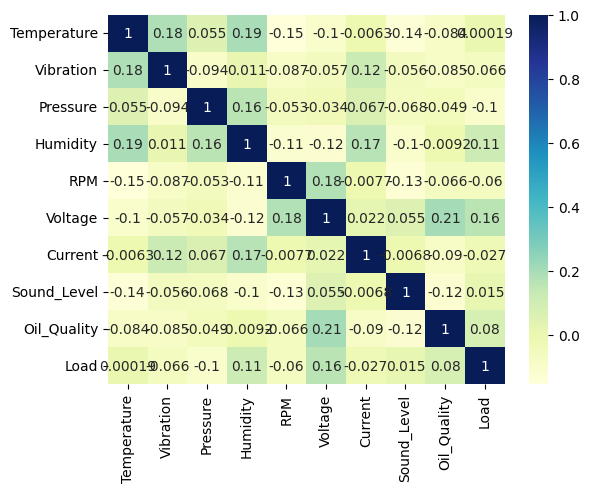

In [8]:
co_mtx = pred.corr(numeric_only=True)

print(co_mtx)

sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

plt.show()

# **Random Forest**

In [9]:
for col in pred:
  if pred[col].dtype == 'O':
    codes, _ = pd.factorize(pred[col])
    pred[col] = codes

In [10]:
X = pred[['Temperature', 'Vibration', 'Pressure', 'Humidity', 'RPM', 'Voltage', 'Current', 'Sound_Level', 'Oil_Quality','Load',
          'Failure Type','Component Type','Machine Type']]
y = pred['Component Type']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred, average='weighted'))
print('Precision:', precision_score(y_test, y_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred, average='weighted'))
print('classification_report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.9
Recall: 0.9
Precision: 0.95
F1 Score: 0.8916666666666666
classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00         6
           2       0.50      1.00      0.67         2
           3       1.00      0.33      0.50         3

    accuracy                           0.90        20
   macro avg       0.88      0.83      0.79        20
weighted avg       0.95      0.90      0.89        20



In [13]:
model = RandomForestRegressor(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Mean Absolute Error:', np.mean(np.abs(y_test - y_pred)))

Mean Absolute Error: 0.0


# **Bagging**

In [14]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier(random_state=42))])

In [15]:
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred, average='weighted'))
print('Precision:', precision_score(y_test, y_pred, average='weighted'))
print('F1 Score:', f1_score(y_test, y_pred, average='weighted'))
print('classification_report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.9
Recall: 0.9
Precision: 0.95
F1 Score: 0.8916666666666666
classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00         6
           2       0.50      1.00      0.67         2
           3       1.00      0.33      0.50         3

    accuracy                           0.90        20
   macro avg       0.88      0.83      0.79        20
weighted avg       0.95      0.90      0.89        20

